<a href="https://colab.research.google.com/github/Aoiizu/PCVK2026/blob/main/PCVK2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving ktm.png to ktm (3).png


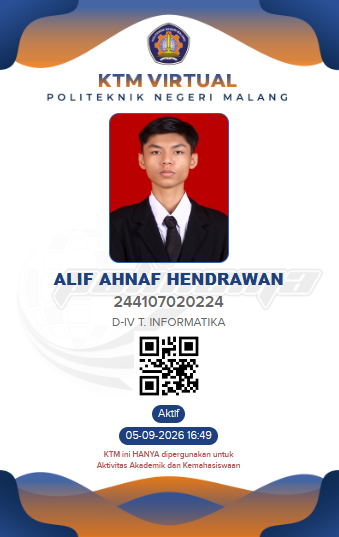

Resolusi gambar:  339  x  537


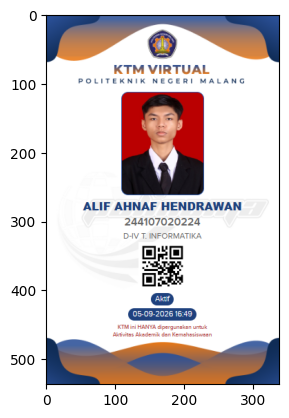

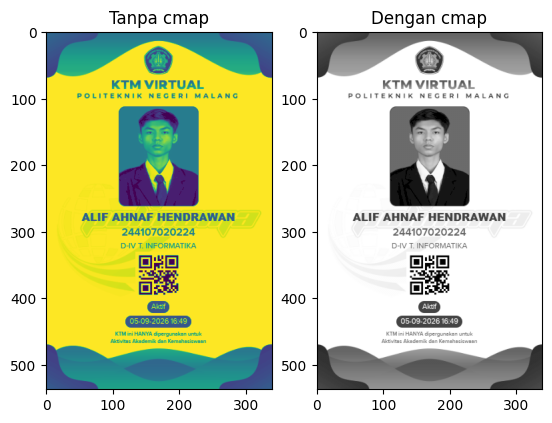

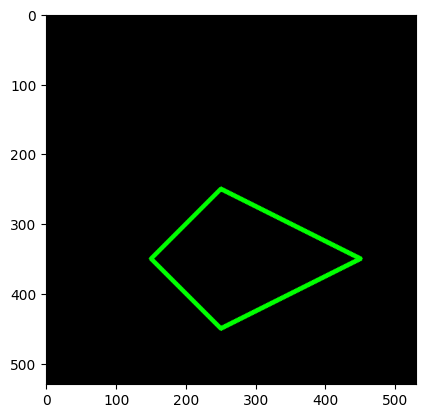

In [18]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

from google.colab import drive
drive.mount('/content/drive')

from google.colab import files
uploaded = files.upload()

img = cv.imread('ktm.png')
cv2_imshow(img)

print("Resolusi gambar: ", img.shape[1], " x ", img.shape[0])

img = cv.imread('ktm.png')
plt.imshow(img)

img = cv.imread('ktm.png')
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.show()

img_gray = cv.imread('ktm.png', cv.IMREAD_GRAYSCALE)

plt.subplot(1,2,1)
plt.imshow(img_gray)
plt.title('Tanpa cmap')

plt.subplot(1,2,2)
plt.imshow(img_gray, cmap='gray')
plt.title('Dengan cmap')

plt.show()

plt.imshow(img_gray, cmap='magma')

imgRGB = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img_output = cv.resize(imgRGB, (347,229))
plt.imshow(img_output)

imgFlip = cv.flip(img_output, 1)
plt.imshow(imgFlip)

black_img = np.zeros(shape=(530,530,3), dtype=np.int16)
plt.imshow(black_img)

cv.rectangle(black_img, pt1=(290,0), pt2=(520,130), color=(0,0,255), thickness=10)
plt.imshow(black_img)

cv.rectangle(black_img, pt1=(250,250), pt2=(350,350), color=(255,0,0), thickness=15)
plt.imshow(black_img)

cv.circle(black_img, center=(150,150), radius=60, color=(0,255,0), thickness=8)
plt.imshow(black_img)

cv.circle(black_img, center=(400,400), radius=50, color=(0,255,0), thickness=-1)
cv.line(black_img, pt1=(0,0), pt2=(530,530), color=(255,255,255), thickness=5)
plt.imshow(black_img)

font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(black_img, text='PCVK is fun!', org=(10,500), fontFace=font, fontScale=2,
           color=(255,255,0), thickness=3, lineType=cv.LINE_AA)
plt.imshow(black_img)

black_img2 = np.zeros(shape=(530,530,3), dtype=np.int32)
plt.imshow(black_img2)

vertices = np.array([[150,350],[250,250],[450,350],[250,450]], dtype=np.int32)
vertices

pts = vertices.reshape((-1,1,2))
pts

cv.polylines(black_img2, [pts], isClosed=True, color=(0,255,0), thickness=5)
plt.imshow(black_img2)


1. Display an image using both `cv2_imshow()` and `plt.imshow()` without performing any color conversion. Why do the results differ? Demonstrate this by printing the value of the same single pixel obtained from both reading methods.

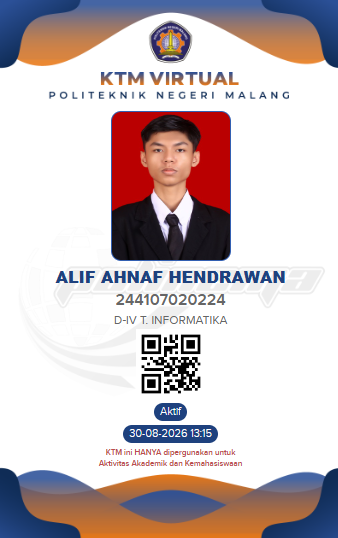

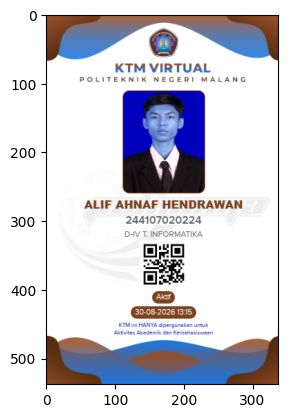

[ 69 130 209]


In [36]:

img = cv.imread('/content/drive/MyDrive/Foto /ktm.png')
cv2_imshow(img)
plt.imshow(img)
plt.show()
print(img[50, 50])

2. Create black canvases of the same size using the `int16` and `int32` data types.
Compare the `dtype`, `min()`, `max()`, and `nbytes` of both. Do they look
different? Is the memory size different? Explain the reasons.

Answer : 4 vs 2 Byte Values which is Taking more RAM

In [37]:
black_16 = np.zeros((530, 530, 3), dtype=np.int16)
black_32 = np.zeros((530, 530, 3), dtype=np.int32)
print(black_16.dtype, black_16.min(), black_16.max(), black_16.nbytes)
print(black_32.dtype, black_32.min(), black_32.max(), black_32.nbytes)

int16 0 0 1685400
int32 0 0 3370800


3. What is the purpose of the line `from google.colab.patches import cv2_imshow`, and why can't OpenCV's built-in `cv2.imshow()` be used in Google Colab?

Answer : This lets images be shown as cell output in Colab

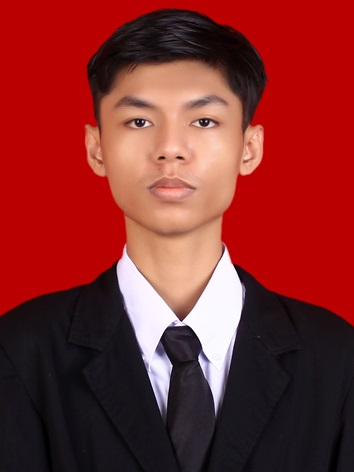

In [75]:
from google.colab.patches import cv2_imshow
cv2_imshow(img)

4. The image read using `skimage.io.imread()` is displayed side-by-side with the result of `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` applied to the same image. Which one displays the true colors, and which one has swapped channels? Prove this using pixel values, rather than relying solely on visual observation.

Answer : skimage.io.imread() reads RGB natively, and converting BGR→RGB gives the same result

In [77]:
from skimage import io as skio
path = '/content/drive/MyDrive/Foto/ktm.png'
img_bgr = cv.imread(path)
img_skim = skio.imread(path)
img_conv = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
print(img_skim[50, 50])
print(img_conv[50, 50])

[209 130  69 255]
[209 130  69]


5. After the image is displayed with a much larger `figsize`, does the value of `img.shape` change? Explain the difference between resizing the image itself and resizing the display.

Answer : img.shape stays the same even with a much larger figsize. figsize only changes the display canvas size

(472, 354, 3)


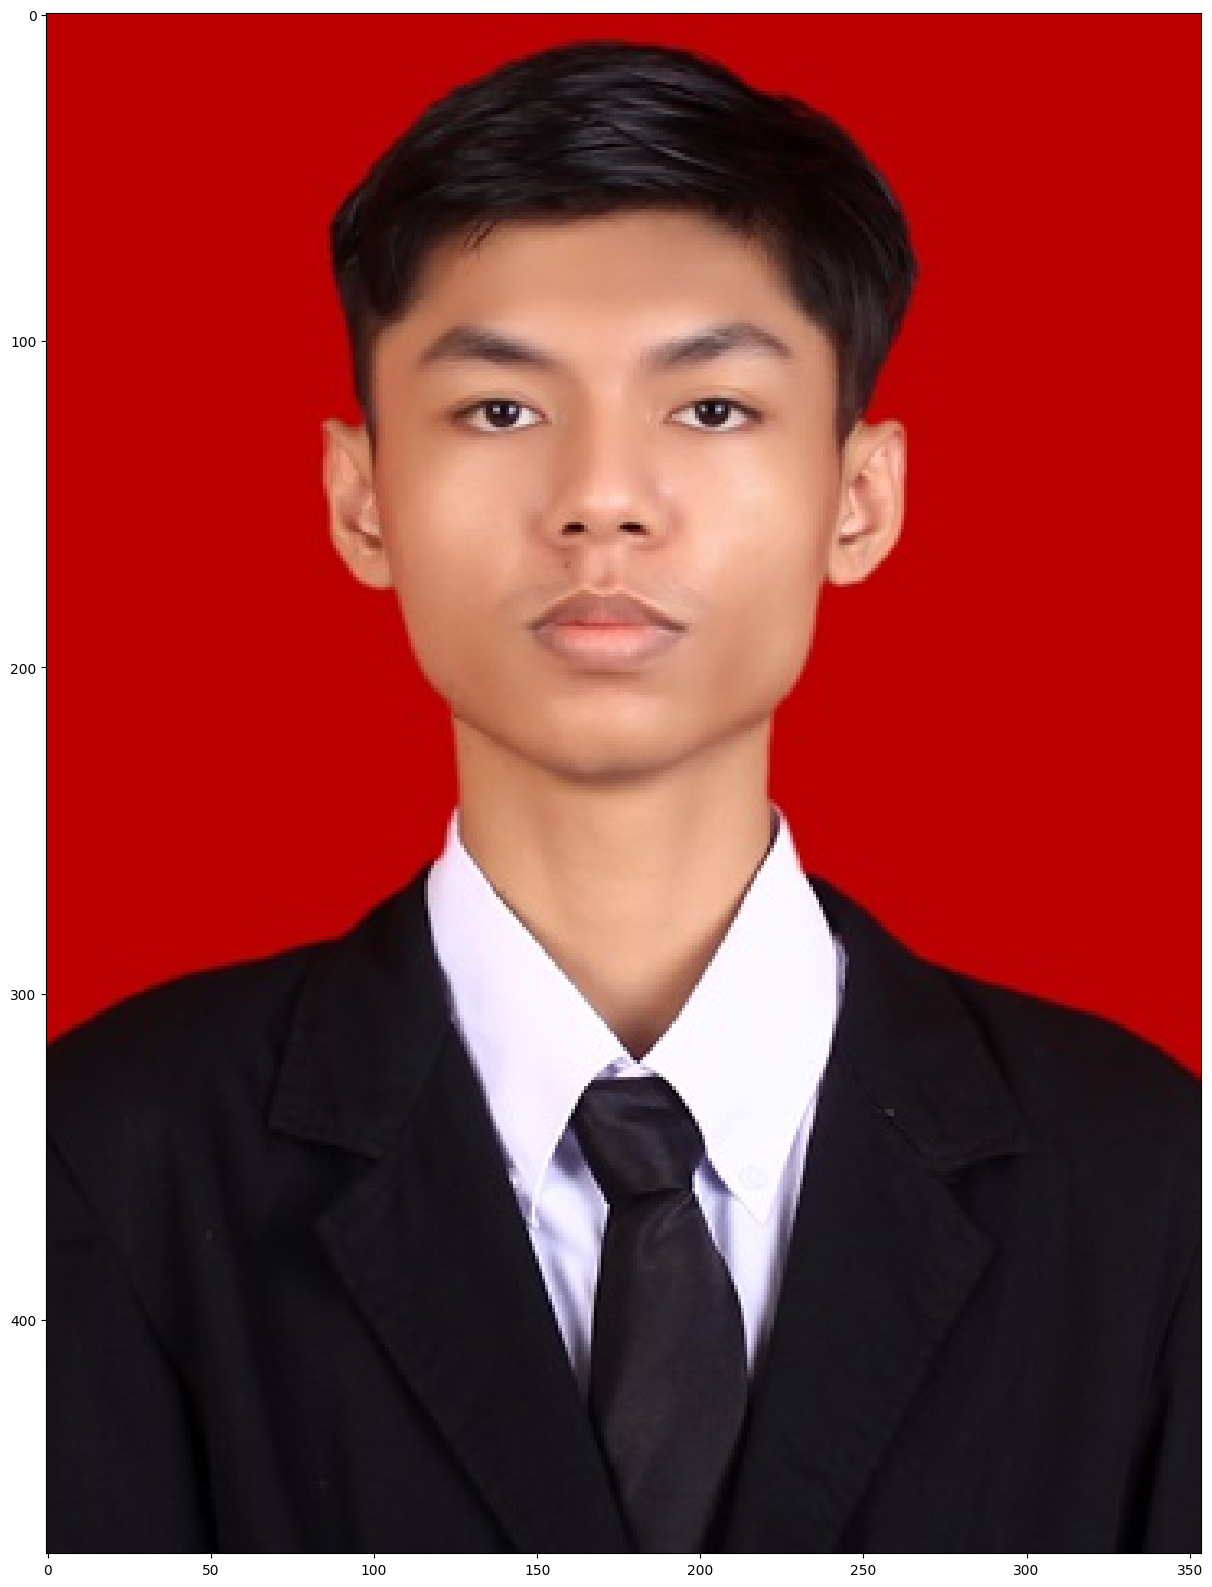

(472, 354, 3)


In [76]:
print(img.shape)
fig = plt.figure(figsize=(20, 20))
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.show()
print(img.shape)

**PRACTICE**

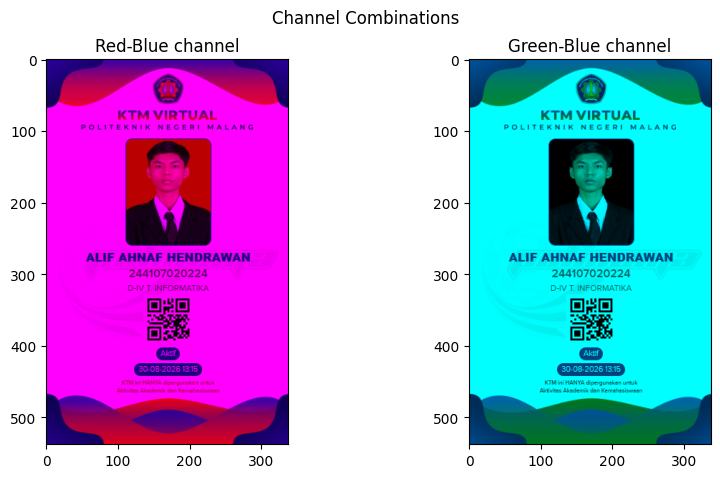

In [40]:
path = '/content/drive/MyDrive/Foto/ktm.png'
img = cv.imread(path)
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

rb = img_rgb.copy()
rb[:, :, 1] = 0

gb = img_rgb.copy()
gb[:, :, 0] = 0

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(rb)
ax[0].set_title('Red-Blue channel')
ax[1].imshow(gb)
ax[1].set_title('Green-Blue channel')
fig.suptitle('Channel Combinations')
plt.show()

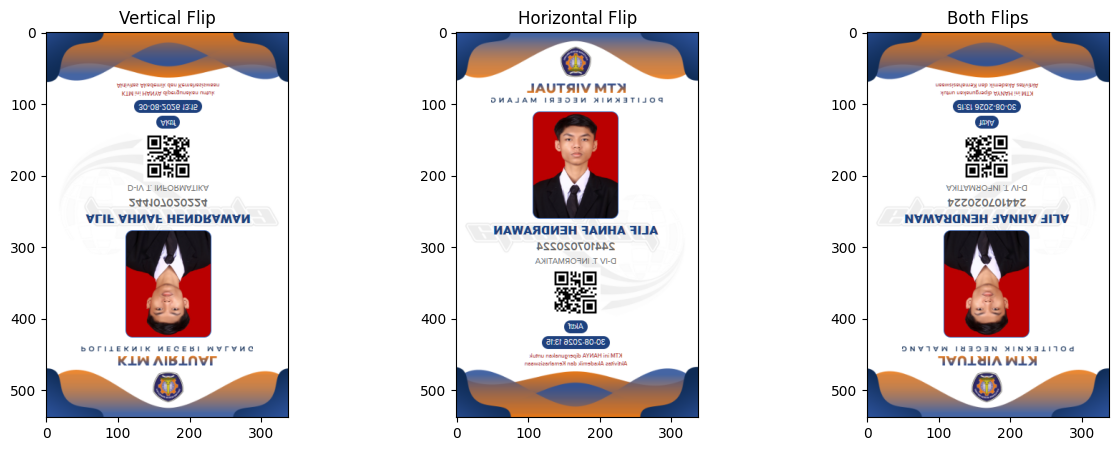

In [41]:
img_rgb = cv.cvtColor(cv.imread(path), cv.COLOR_BGR2RGB)

flip_v = cv.flip(img_rgb, 0)
flip_h = cv.flip(img_rgb, 1)
flip_vh = cv.flip(img_rgb, -1)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(flip_v)
ax[0].set_title('Vertical Flip')
ax[1].imshow(flip_h)
ax[1].set_title('Horizontal Flip')
ax[2].imshow(flip_vh)
ax[2].set_title('Both Flips')
plt.show()

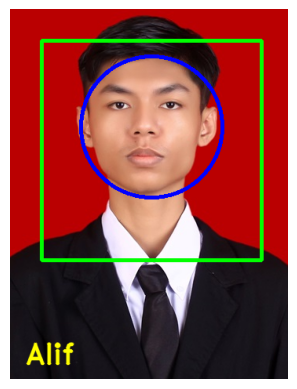

In [71]:
img = cv.imread('/content/drive/MyDrive/Foto/20242930011-6ZJKj.jpg')
img_draw = img.copy()

cv.rectangle(img_draw, (40, 40), (320, 320), (0, 255, 0), 4)
cv.circle(img_draw, (180, 150), 90, (255, 0, 0), 3)

font = cv.FONT_HERSHEY_DUPLEX
cv.putText(img_draw, 'Alif', (20, img_draw.shape[0]-20), font, 1.2, (0, 255, 255), 2, cv.LINE_AA)

plt.imshow(cv.cvtColor(img_draw, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

**Practicum Analysis**

In [73]:
img_gray = cv.imread('/content/drive/MyDrive/Foto/ktm.png', cv.IMREAD_GRAYSCALE)

total_pixels = img_gray.size
dark_pixels = np.sum(img_gray < 100)
percentage = dark_pixels / total_pixels * 100

print(total_pixels)
print(dark_pixels)
print(percentage)

181844
23824
13.101339609775412


Conclusion : 13% of the pixels are darker than 100, mostly from the text and photo area

**Practicum Application**


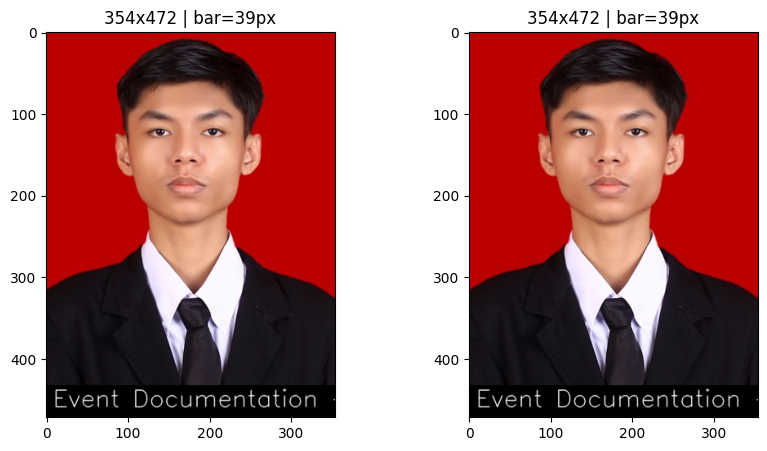

In [74]:
def add_label(path, label_text):
    img = cv.imread(path)
    h, w = img.shape[:2]

    bar_height = h // 12
    y1 = h - bar_height
    result = img.copy()

    cv.rectangle(result, (0, y1), (w, h), (0, 0, 0), -1)

    font_scale = bar_height / 40.0
    thickness = max(1, bar_height // 25)
    margin_x = w // 40
    baseline_y = h - bar_height // 3

    cv.putText(result, label_text, (margin_x, baseline_y), cv.FONT_HERSHEY_SIMPLEX, font_scale, (255, 255, 255), thickness, cv.LINE_AA)

    return result, bar_height

path1 = '/content/drive/MyDrive/Foto/Copy of 20242930011-6ZJKj.jpg'
path2 = '/content/drive/MyDrive/Foto/20242930011-6ZJKj.jpg'

img1, bar1 = add_label(path1, 'Event Documentation - 2026')
img2, bar2 = add_label(path2, 'Event Documentation - 2026')

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(cv.cvtColor(img1, cv.COLOR_BGR2RGB))
ax[0].set_title(f'{img1.shape[1]}x{img1.shape[0]} | bar={bar1}px')
ax[1].imshow(cv.cvtColor(img2, cv.COLOR_BGR2RGB))
ax[1].set_title(f'{img2.shape[1]}x{img2.shape[0]} | bar={bar2}px')
plt.show()